In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results_folder = "../results/TimeSeries/3D"
folders = [results_folder + "/1_color", results_folder + "/rho"]
for folder in folders:
    create_folder(folder)

results_folder_pt = "../results/TimeSeries/3D/define_pt/"
create_folder(results_folder_pt)

Folder already exists: ../results/TimeSeries/3D/1_color
Folder already exists: ../results/TimeSeries/3D/rho
Folder already exists: ../results/TimeSeries/3D/define_pt/


# TIME SERIES - 1 COLOR

In [39]:
process_all_data()

Processamento finalizado.


In [2]:
df = pd.read_csv("../Data/bond_percolation/all_data.dat", sep=',')
df

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,2,512,200,0.000100,1,1.000,1.0,0.1,1,400,0.517403,0.000036,902.727500,1.136105,1.853617e+05,2.274492e+02
1,2,1024,200,0.000100,1,1.000,1.0,0.1,1,300,0.503709,0.000024,2479.286667,10.155359,5.008074e+05,2.028820e+03
2,2,2000,200,0.000100,1,1.000,1.0,0.1,1,1,NaN,NaN,5915.000000,0.000000,1.186322e+06,0.000000e+00
3,2,2048,200,0.000100,1,1.000,1.0,0.1,1,200,0.501545,0.000019,6809.170000,74.156827,1.351225e+06,1.596092e+04
4,2,2048,400,0.000010,2,0.125,1.0,0.1,1,100,0.515791,0.000016,3799.390000,4.583477,1.135726e+06,3.008000e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14220,3,1024,3000,0.000001,8,0.125,1.0,0.1,4,10,0.250154,0.000008,6931.000000,57.165646,1.709806e+07,1.285516e+06
14221,3,1024,3000,0.000001,8,0.125,1.0,0.1,5,10,0.250229,0.000008,6830.500000,44.251365,1.589769e+07,1.168986e+06
14222,3,1024,3000,0.000001,8,0.125,1.0,0.1,6,10,0.250165,0.000008,6862.700000,70.860277,1.644904e+07,9.010302e+05
14223,3,1024,3000,0.000001,8,0.125,1.0,0.1,7,10,0.250329,0.000008,6942.800000,31.849926,1.757772e+07,1.257520e+06


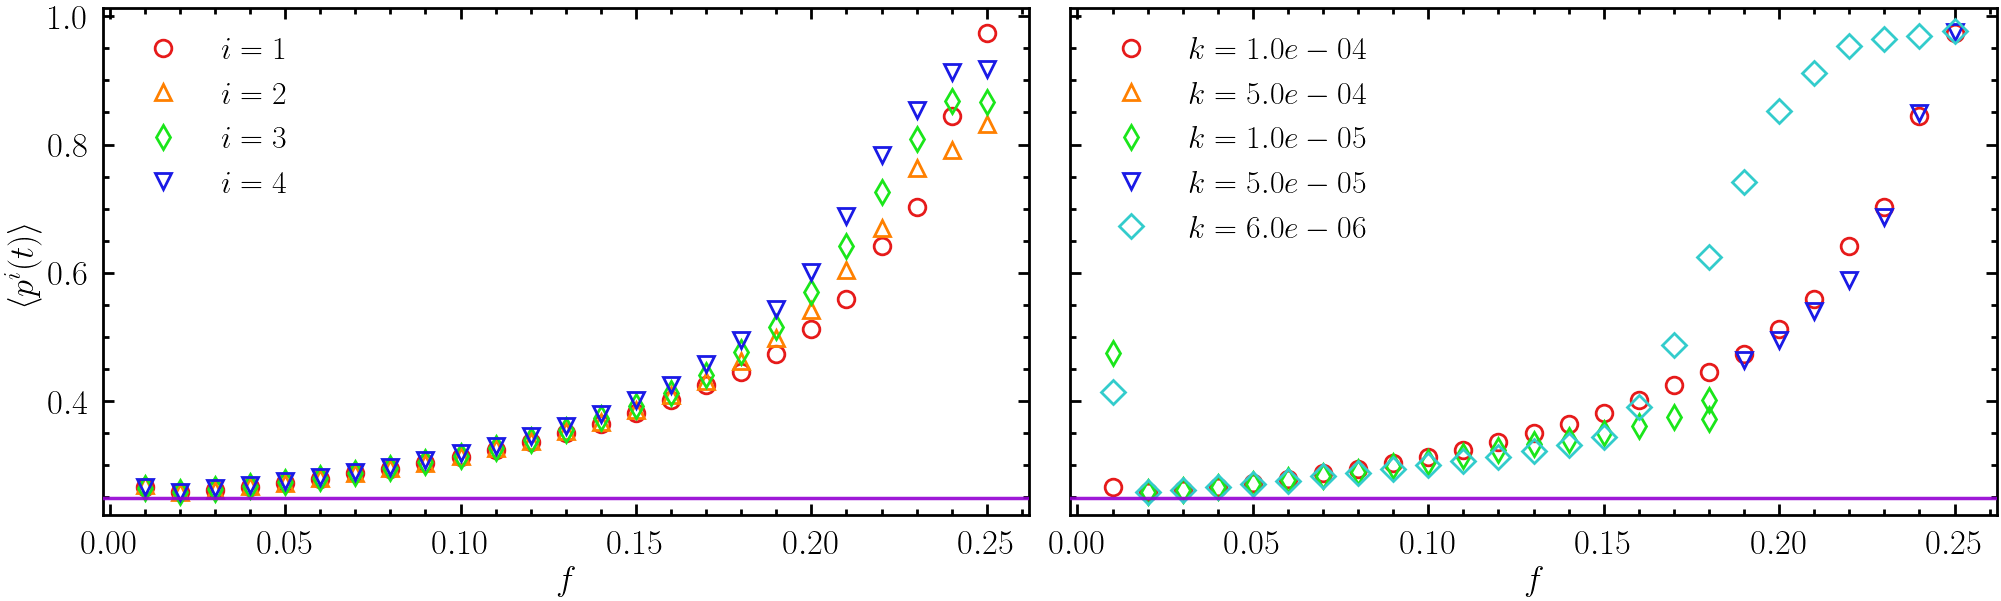

In [52]:
k_lst = [1.0e-04, 5.0e-04, 1.0e-05, 5.0e-05, 6.0e-06]
L = 128
A = L**2
orders = [i for i in range(1,5)]
colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 2, figsize=(20, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==128) & (df['rho']==0.25) & (df['nc']==4) & (df['k']==k_lst[0]) & (df['order']==ord)]
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')

for idx, k in enumerate(k_lst):
    df_sub = df[(df['L']==128) & (df['rho']==0.25) & (df['nc']==4) & (df['k']==k) & (df['order']==1)]
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    axes[1].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$k = {k:.1e}$')

for ax in axes:
    ax.legend(fontsize=fs_legend)
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
plt.show()

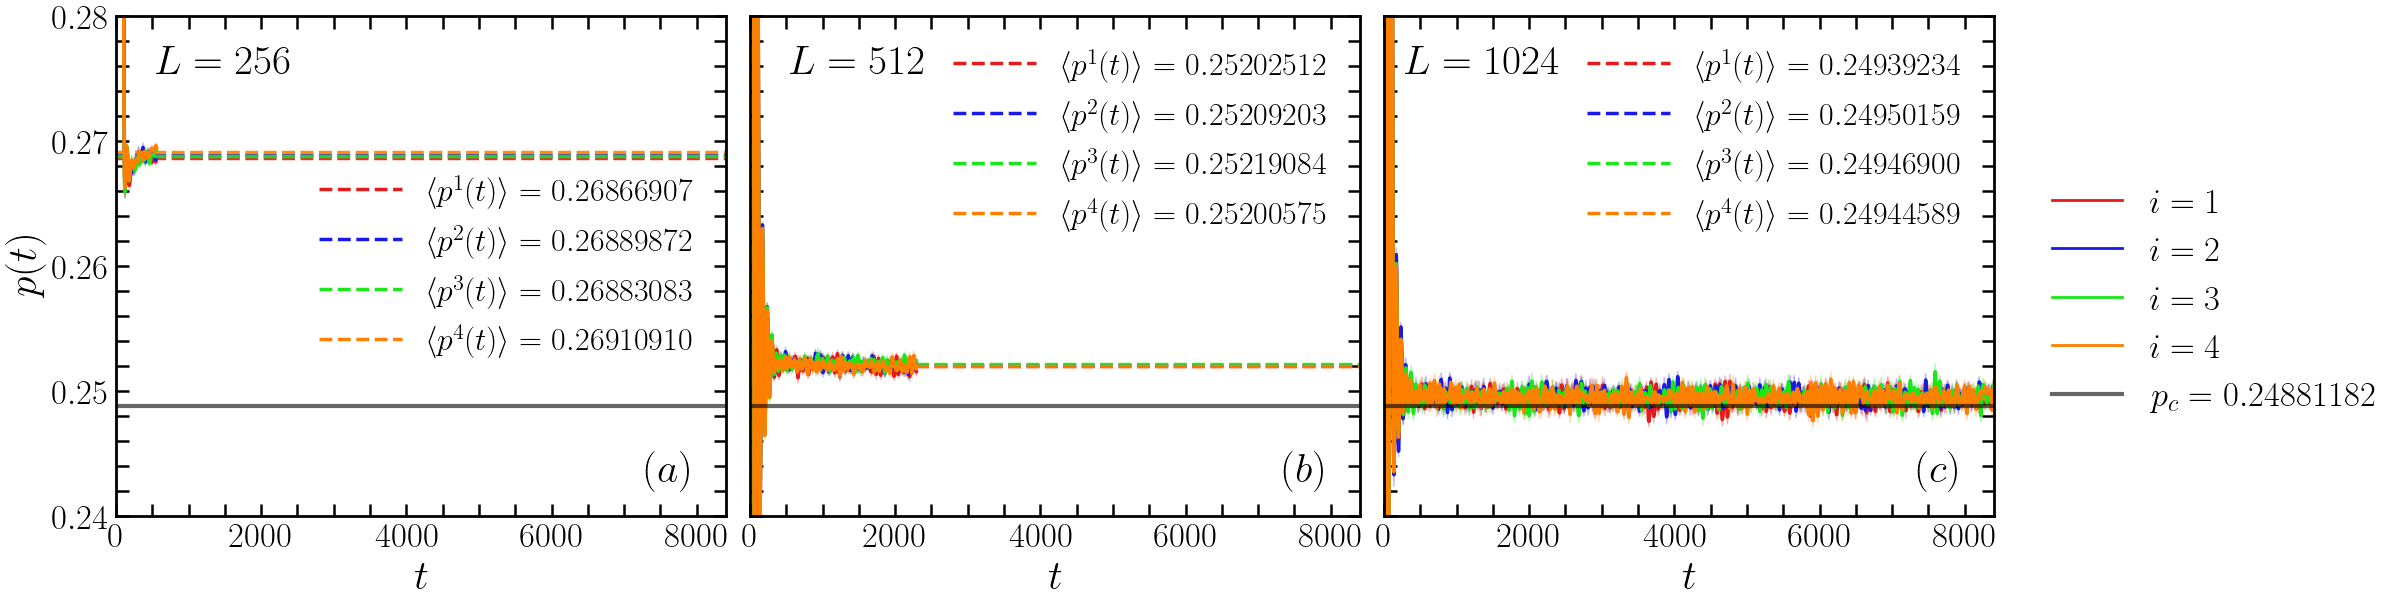

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# DIM = 3
# N_COLORS = 4
# NT = 3000
# K = 1.0e-6
# RHO = 1 / N_COLORS

# L_lst = [256, 512, 1024]

# colors_used = [
#     (0.9, 0.1, 0.1),
#     (0.1, 0.1, 0.9),
#     (0.1, 0.9, 0.1),
#     (1.0, 0.5, 0.0),
#     (0.8, 0.2, 0.8),
#     (0.2, 0.8, 0.8),
#     (1.0, 1.0, 0.0),
#     (0.6, 0.4, 0.2),
# ]

# pc = 0.24881182

# # =======================
# # PARÂMETROS DE ESTILO
# # =======================
# fs_ticks = 25            # fontsize dos ticks
# fs_labels = 30           # fontsize dos labels (x/y)
# fs_legend_global = 25    # fontsize da legenda global (fora)
# fs_legend_local = 23    # fontsize da legenda local (dentro)
# fs_text = 30             # fontsize dos textos (L e (a),(b)...)

# lw_dados = 2.5           # linewidth das curvas p(t)
# lw_pmean = 2.5           # linewidth das linhas mean_eq (tracejado)
# lw_pc = 3.0              # linewidth da linha p_c (horizontal)
# # =======================

# fig, axes = plt.subplots(
#     1, 3, figsize=(20, 6),
#     sharey=True,
#     sharex=True,
#     constrained_layout=True
# )

# axes = np.atleast_1d(axes)
# labels_alfa = ['$(a)$', '$(b)$', '$(c)$']

# for idx_ax, (ax, L) in enumerate(zip(axes, L_lst)):

#     orders, num_seeds = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)

#     if isinstance(orders, dict):
#         if "0" in orders:
#             orders = [orders[str(i)] for i in range(N_COLORS)]
#         else:
#             orders = [orders[i] for i in range(N_COLORS)]

#     series = []
#     for i in range(N_COLORS):
#         d = orders[i]["data"]
#         t = np.array(d["time"], dtype=float)
#         pt = np.array(d["pt_mean"], dtype=float)
#         pt_sem = np.array(d["pt_sem"], dtype=float)
#         series.append((t, pt, pt_sem))

#     t0_ind = []
#     for (t, pt, pt_sem) in series:
#         idx0_i = detect_equilibrium_start_with_errors(
#             t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0
#         )
#         t0_ind.append(float(t[idx0_i]))
#     t0_global = float(max(t0_ind))

#     mean_eq_list = []

#     for i, (t, pt, pt_sem) in enumerate(series):
#         idx0_g = idx_from_t0(t, t0_global)
#         mean_eq, sem_eq = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
#         mean_eq_list.append(mean_eq)

#         err = (abs(mean_eq - pc) / pc) * 100
        

#         ax.plot(t, pt, ls='-', color=colors_used[i], lw=lw_dados)
#         ax.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])
#         ax.axhline(mean_eq, linestyle="--", linewidth=lw_pmean, alpha=0.9, color=colors_used[i])

#     ax.axhline(y=pc, linestyle="-", color="k", linewidth=lw_pc, alpha=0.6)

#     ax.set_xlim(0, max(series[0][0]))
#     ax.set_ylim(0.24, 0.28)

#     # labels
#     ax.set_xlabel(r"$t$", fontsize=fs_labels)
#     if idx_ax == 0:
#         ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)
#     else:
#         ax.set_ylabel("")

#     # ticks (numéricos em todos)
#     ax.tick_params(axis='both', which='both',width=1.8, length=9, labelsize=fs_ticks)
#     ax.tick_params(axis='x', labelbottom=True)

#     # legenda local
#     local_handles = [
#         Line2D([0], [0], color=colors_used[i], lw=lw_pmean, linestyle="--",
#                label=rf"$\langle p^{i+1}(t) \rangle={mean_eq_list[i]:.8f}$")
#         for i in range(N_COLORS)
#     ]
#     ax.legend(
#         handles=local_handles,
#         loc="best",
#         frameon=False,
#         fontsize=fs_legend_local,
#         handlelength=2.6,
#         borderaxespad=0.6
#     )

#     # textos (a),(b),(c) e L
#     ax.text(0.95, 0.05, labels_alfa[idx_ax],
#             transform=ax.transAxes, ha='right', va='bottom',
#             fontsize=fs_text)

#     ax.text(0.29, 0.87, f"$L = {L}$",
#             transform=ax.transAxes, ha='right', va='bottom',
#             fontsize=fs_text)

# # legenda global
# handles_i = [
#     Line2D([0], [0], color=colors_used[i], lw=2, label=fr"$i={i+1}$")
#     for i in range(N_COLORS)
# ]
# handle_pc = Line2D([0], [0], color="k", lw=lw_pc, linestyle="-", alpha=0.6,
#                    label=rf"$p_c={pc:.8f}$")

# fig.legend(
#     handles=handles_i + [handle_pc],
#     loc="center left",
#     bbox_to_anchor=(1.01, 0.5),
#     frameon=False,
#     ncol=1,
#     fontsize=fs_legend_global
# )

# plt.savefig(results_folder_pt + "pc_versus_L.pdf")
# plt.show()



=== L=256 ===
N_samples (num_seeds) nc=2 -> 200
N_samples (num_seeds) nc=4 -> 200
N_samples (num_seeds) nc=8 -> 200
t0 GLOBAL (usado para TODAS no subplot L=256): 603.00

=== L=512 ===
N_samples (num_seeds) nc=2 -> 50
N_samples (num_seeds) nc=4 -> 50
N_samples (num_seeds) nc=8 -> 50
t0 GLOBAL (usado para TODAS no subplot L=512): 658.00

=== L=1024 ===
N_samples (num_seeds) nc=2 -> 10
N_samples (num_seeds) nc=4 -> 20
N_samples (num_seeds) nc=8 -> 10
t0 GLOBAL (usado para TODAS no subplot L=1024): 620.00


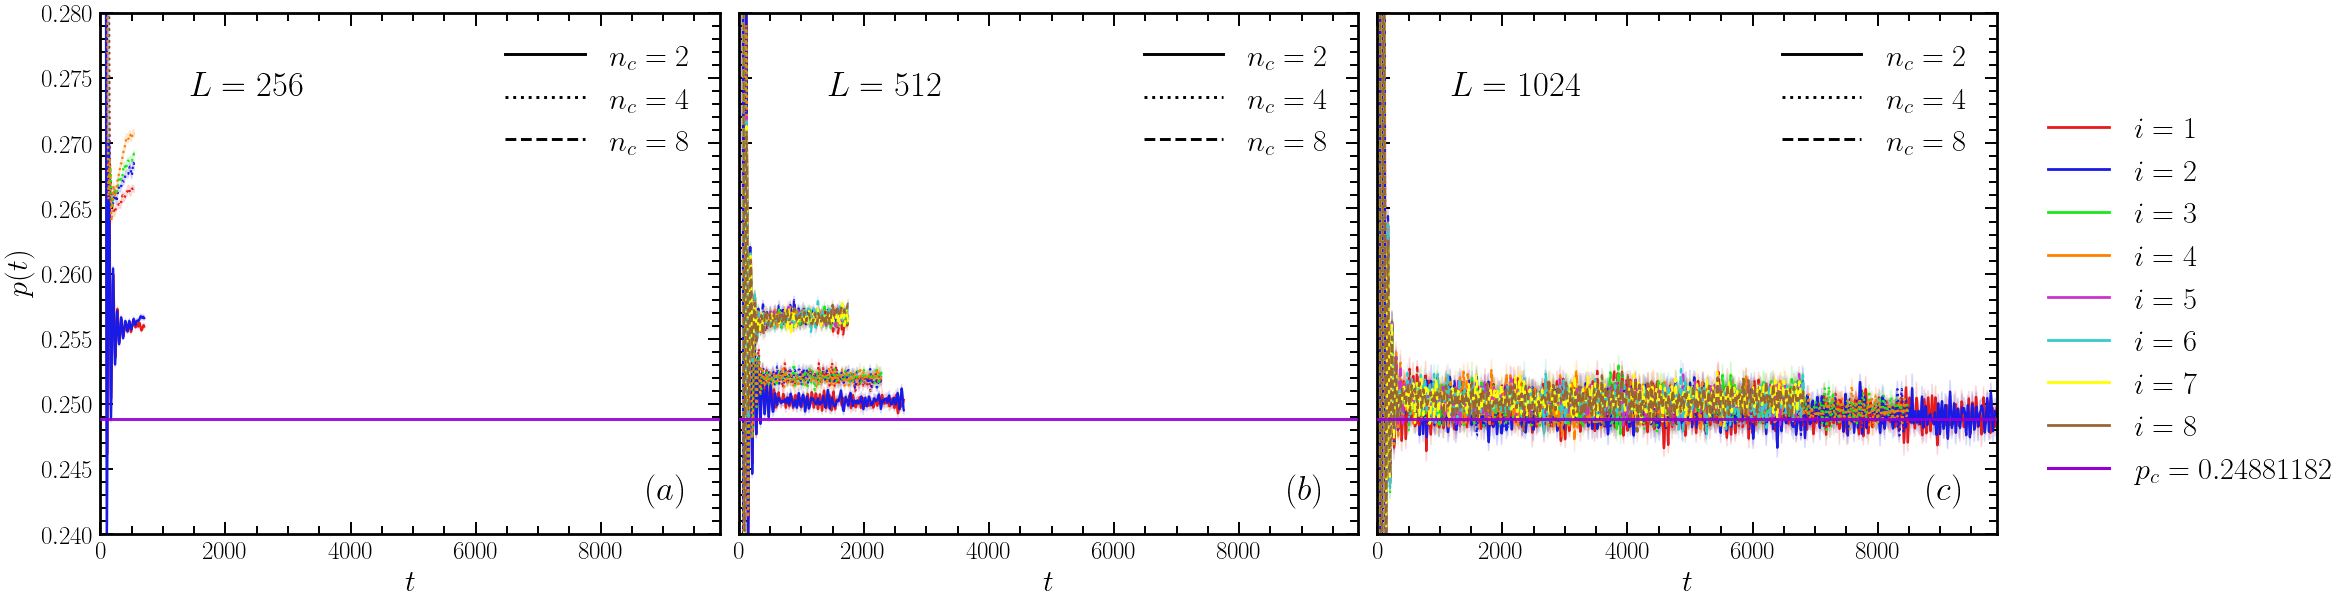

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# DIM = 3
# NT = 3000
# K = 1.0e-6

# L_lst = [256, 512, 1024]

# # agora vamos plotar nc = 2, 4, 8 em CADA L
# NC_LIST = [2, 4, 8]
# LS_BY_NC = {2: "solid", 4: "dotted", 8: "dashed"}  # estilos por nc

# colors_used = [
#     (0.9, 0.1, 0.1),
#     (0.1, 0.1, 0.9),
#     (0.1, 0.9, 0.1),
#     (1.0, 0.5, 0.0),
#     (0.8, 0.2, 0.8),
#     (0.2, 0.8, 0.8),
#     (1.0, 1.0, 0.0),
#     (0.6, 0.4, 0.2),
# ]

# pc = 0.24881182
# rho = 0.125

# # =======================
# # PARÂMETROS DE ESTILO
# # =======================
# fs_ticks = 18            # fontsize dos ticks
# fs_labels = 22           # fontsize dos labels (x/y)
# fs_legend_global = 22    # fontsize da legenda global (fora)
# fs_legend_local = 22     # fontsize da legenda local (dentro)
# fs_text = 25             # fontsize dos textos (L e (a),(b)...)

# lw_dados = 1.6           # linewidth das curvas p(t)
# lw_pmean = 2.1           # linewidth das linhas da legenda interna (nc) e/ou referências
# lw_pc = 2.2              # linewidth da linha p_c (horizontal)
# # =======================

# fig, axes = plt.subplots(
#     1, 3, figsize=(20, 6),
#     sharey=True,
#     sharex=True,
#     constrained_layout=True
# )

# axes = np.atleast_1d(axes)
# labels_alfa = ['$(a)$', '$(b)$', '$(c)$']

# for idx_ax, (ax, L) in enumerate(zip(axes, L_lst)):

#     # acumula todas as series de TODOS os nc para definir um t_eq GLOBAL por subplot (por L)
#     all_series = []  # lista de dicts: {nc, i, t, pt, sem}
#     num_seeds_by_nc = {}

#     for nc in NC_LIST:
#         # rho = 1.0 / nc
#         orders, num_seeds = read_mean_json(nc, DIM, L, NT, K, rho)
#         num_seeds_by_nc[nc] = num_seeds

#         if isinstance(orders, dict):
#             if "0" in orders:
#                 orders = [orders[str(i)] for i in range(nc)]
#             else:
#                 orders = [orders[i] for i in range(nc)]

#         for i in range(nc):
#             d = orders[i]["data"]
#             t = np.array(d["time"], dtype=float)
#             pt = np.array(d["pt_mean"], dtype=float)
#             pt_sem = np.array(d["pt_sem"], dtype=float)
#             all_series.append({"nc": nc, "i": i, "t": t, "pt": pt, "sem": pt_sem})

#     print(f"\n=== L={L} ===")
#     for nc in NC_LIST:
#         print(f"N_samples (num_seeds) nc={nc} -> {num_seeds_by_nc[nc]}")

#     # t_eq: calcula t0 por série e pega o máximo (para usar em todas as curvas do subplot)
#     t0_ind = []
#     for s in all_series:
#         t, pt, sem = s["t"], s["pt"], s["sem"]
#         idx0_i = detect_equilibrium_start_with_errors(
#             t, pt, sem, w=40, consec=6, z=2.0, chi2r_max=2.0
#         )
#         t0_ind.append(float(t[idx0_i]))
#     t0_global = float(max(t0_ind))

#     print(f"t0 GLOBAL (usado para TODAS no subplot L={L}): {t0_global:.2f}")

#     # plot: cor = i, linestyle = nc
#     for s in all_series:
#         nc, i = s["nc"], s["i"]
#         t, pt, sem = s["t"], s["pt"], s["sem"]
#         ls = LS_BY_NC[nc]
#         color = colors_used[i]  # i=0..(nc-1)

#         ax.plot(t, pt, ls=ls, color=color, lw=lw_dados)
#         ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=color)

#     # linhas de referência
#     # ax.axvline(t0_global, linestyle="--", linewidth=1.5, color="k", alpha=0.7)
#     ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

#     # limites
#     ax.set_xlim(0, max(all_series[0]["t"]))
#     ax.set_ylim(0.24, 0.28)

#     # --------- MESMAS MUDANÇAS DO OUTRO CÓDIGO ---------

#     # xlabel em TODOS os plots
#     ax.set_xlabel(r"$t$", fontsize=fs_labels)

#     # ylabel apenas no primeiro subplot (à esquerda)
#     if idx_ax == 0:
#         ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)
#     else:
#         ax.set_ylabel("")

#     # ticks numéricos em TODOS + fontsize configurável
#     ax.tick_params(axis='both', which='both', labelsize=fs_ticks)
#     ax.tick_params(axis='x', labelbottom=True)

#     # ---------------------------------------------------

#     # legenda interna: SOMENTE nc (estilos)
#     inner_handles = [
#         Line2D([0], [0], color="k", lw=lw_pmean, linestyle=LS_BY_NC[nc], label=fr"$n_c={nc}$")
#         for nc in NC_LIST
#     ]
#     ax.legend(
#         handles=inner_handles,
#         loc="best",
#         frameon=False,
#         fontsize=fs_legend_local,
#         handlelength=2.6,
#         borderaxespad=0.6
#     )

#     ax.text(0.95, 0.05, labels_alfa[idx_ax],
#             transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

#     ax.text(0.33, 0.83, f"$L = {L}$",
#             transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

# # legenda global única (fora): SOMENTE cores (i), até i=8 (pois nc_max=8)
# handles_i = [
#     Line2D([0], [0], color=colors_used[i], lw=2, label=fr"$i={i+1}$")
#     for i in range(8)
# ]
# handle_pc = Line2D(
#     [0], [0],
#     color="darkviolet",
#     lw=lw_pc,
#     linestyle="-",
#     label=rf"$p_c = {pc:.8f}$"
# )

# fig.legend(
#     handles=handles_i + [handle_pc],
#     loc="center left",
#     bbox_to_anchor=(1.01, 0.5),
#     frameon=False,
#     ncol=1,
#     fontsize=fs_legend_global
# )

# plt.savefig(results_folder_pt + "pc_versus_L_all_nc.pdf")
# plt.show()


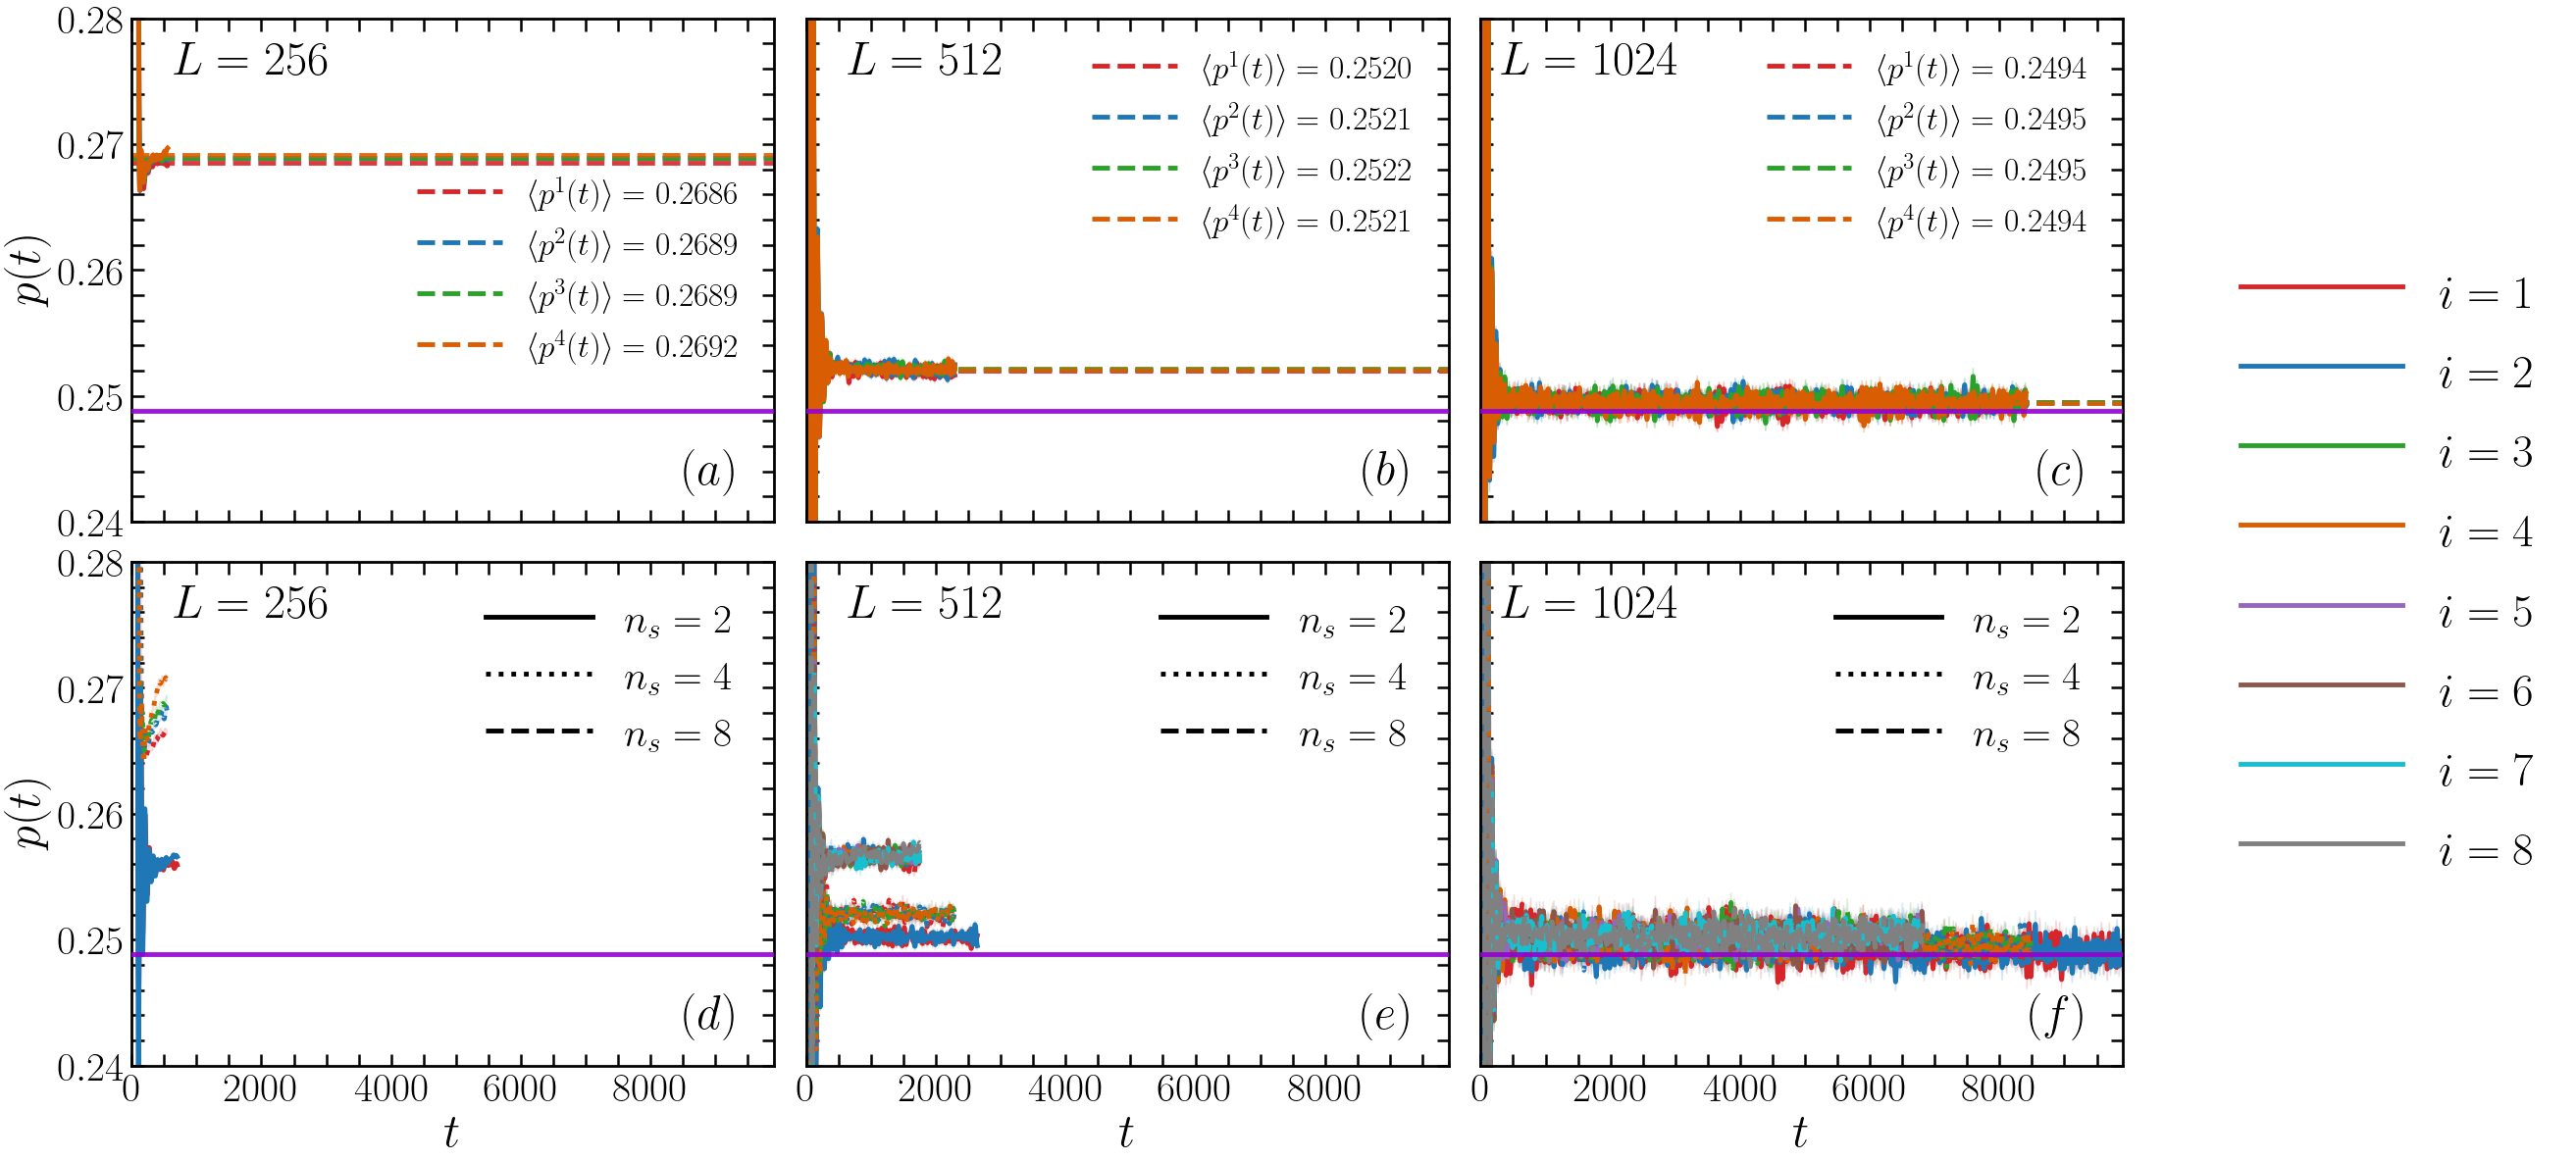

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ================================
# PARÂMETROS GERAIS
# ================================
DIM = 3
NT = 3000
K = 1.0e-6

L_lst = [256, 512, 1024]

colors_used = [
    (0.84, 0.15, 0.16),  # vermelho forte
    (0.12, 0.47, 0.71),  # azul profundo
    (0.17, 0.63, 0.17),  # verde médio escuro
    (0.85, 0.37, 0.01),  # laranja queimado
    (0.58, 0.40, 0.74),  # roxo
    (0.55, 0.34, 0.29),  # marrom
    (0.09, 0.75, 0.81),  # ciano forte (escuro o suficiente)
    (0.50, 0.50, 0.50),  # cinza médio (ótimo para contraste sem brigar)
]

pc = 0.24881182

# =======================
# ESTILO (GLOBAL)
# =======================
fs_ticks = 30
fs_labels = 35
fs_legend_global = 34

# (5) separado por linha
fs_legend_local_top = 24
fs_legend_local_bottom = 30

fs_text = 35

lw_dados = 3.5
lw_pmean = 3.5
lw_pc = 3.5

tick_w = 1.8
tick_len = 9

# ================================
# CONFIGS FIGURA 1 (TOPO)
# ================================
N_COLORS = 4
RHO = 1 / N_COLORS

# ================================
# CONFIGS FIGURA 2 (BAIXO)
# ================================
NC_LIST = [2, 4, 8]
LS_BY_NC = {2: "solid", 4: "dotted", 8: "dashed"}
rho_bottom = 0.125

# ==========================================================
# (3) PRE-PASS: encontrar t_max GLOBAL para compartilhar x
# ==========================================================
t_max_global = 0.0

# topo
for L in L_lst:
    orders, _ = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
    if isinstance(orders, dict):
        if "0" in orders:
            orders = [orders[str(i)] for i in range(N_COLORS)]
        else:
            orders = [orders[i] for i in range(N_COLORS)]
    for i in range(N_COLORS):
        t = np.array(orders[i]["data"]["time"], dtype=float)
        if t.size > 0:
            t_max_global = max(t_max_global, float(np.max(t)))

# baixo
for L in L_lst:
    for nc in NC_LIST:
        orders, _ = read_mean_json(nc, DIM, L, NT, K, rho_bottom)
        if isinstance(orders, dict):
            if "0" in orders:
                orders = [orders[str(i)] for i in range(nc)]
            else:
                orders = [orders[i] for i in range(nc)]
        for i in range(nc):
            t = np.array(orders[i]["data"]["time"], dtype=float)
            if t.size > 0:
                t_max_global = max(t_max_global, float(np.max(t)))

# ================================
# FIGURA 2x3 (x compartilhado)
# ================================
fig, axes = plt.subplots(
    2, 3, figsize=(29, 12),
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.08,
    right=0.78,   # mantém espaço p/ legenda global
    bottom=0.08,
    top=0.97,
    wspace=0.05,  # espaço horizontal (diminuir ↓)
    hspace=0.08   # espaço vertical (diminuir ↓)
)

# (4) labels (a) ... (f)
panel_labels = ['$(a)$', '$(b)$', '$(c)$', '$(d)$', '$(e)$', '$(f)$']

# ============================================================
# ======================= LINHA 1 (FIGURA 1) ==================
# ============================================================
for idx_col, L in enumerate(L_lst):
    ax = axes[0, idx_col]

    orders, _ = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
    if isinstance(orders, dict):
        if "0" in orders:
            orders = [orders[str(i)] for i in range(N_COLORS)]
        else:
            orders = [orders[i] for i in range(N_COLORS)]

    series = []
    for i in range(N_COLORS):
        d = orders[i]["data"]
        t = np.array(d["time"], dtype=float)
        pt = np.array(d["pt_mean"], dtype=float)
        pt_sem = np.array(d["pt_sem"], dtype=float)
        series.append((t, pt, pt_sem))

    # t_eq global por subplot
    t0_ind = []
    for (t, pt, pt_sem) in series:
        idx0_i = detect_equilibrium_start_with_errors(
            t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0
        )
        t0_ind.append(float(t[idx0_i]))
    t0_global = float(max(t0_ind))

    mean_eq_list = []
    for i, (t, pt, pt_sem) in enumerate(series):
        idx0_g = idx_from_t0(t, t0_global)
        mean_eq, _ = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
        mean_eq_list.append(mean_eq)

        ax.plot(t, pt, ls='-', color=colors_used[i], lw=lw_dados)
        ax.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])
        ax.axhline(mean_eq, linestyle="--", linewidth=lw_pmean, alpha=0.9, color=colors_used[i])

    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

    # (3) x compartilhado com t_max_global
    ax.set_xlim(0, t_max_global)
    ax.set_ylim(0.24, 0.28)

    #ax.set_xlabel(r"$t$", fontsize=fs_labels)
    if idx_col == 0:
        ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)

    ax.tick_params(axis='both', which='both', width=tick_w, length=tick_len, labelsize=fs_ticks)

    # (2) legenda local do topo (como na figura 1 separada)
    local_handles = [
        Line2D([0], [0], color=colors_used[i], lw=lw_pmean, linestyle="--",
               label=rf"$\langle p^{i+1}(t) \rangle={mean_eq_list[i]:.4f}$")
        for i in range(N_COLORS)
    ]
    ax.legend(
        handles=local_handles,
        loc="best",
        frameon=False,
        fontsize=fs_legend_local_top,
        handlelength=2.6,
        borderaxespad=0.6
    )

    # (4) rótulos (a)-(f) e texto L
    ax.text(0.95, 0.05, panel_labels[idx_col],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)
    ax.text(0.31, 0.87, f"$L = {L}$",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

# ============================================================
# ======================= LINHA 2 (FIGURA 2) ==================
# ============================================================
for idx_col, L in enumerate(L_lst):
    ax = axes[1, idx_col]

    all_series = []  # (nc, i, t, pt, sem)
    for nc in NC_LIST:
        orders, _ = read_mean_json(nc, DIM, L, NT, K, rho_bottom)
        if isinstance(orders, dict):
            if "0" in orders:
                orders = [orders[str(i)] for i in range(nc)]
            else:
                orders = [orders[i] for i in range(nc)]

        for i in range(nc):
            d = orders[i]["data"]
            t = np.array(d["time"], dtype=float)
            pt = np.array(d["pt_mean"], dtype=float)
            pt_sem = np.array(d["pt_sem"], dtype=float)
            all_series.append((nc, i, t, pt, pt_sem))

    # plot: cor=i, linestyle=nc
    for (nc, i, t, pt, sem) in all_series:
        ax.plot(t, pt, ls=LS_BY_NC[nc], color=colors_used[i], lw=lw_dados)
        ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=colors_used[i])

    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

    # (3) x compartilhado com t_max_global
    ax.set_xlim(0, t_max_global)
    ax.set_ylim(0.24, 0.28)

    ax.set_xlabel(r"$t$", fontsize=fs_labels)
    if idx_col == 0:
        ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)

    ax.tick_params(axis='both', which='both', width=tick_w, length=tick_len, labelsize=fs_ticks)

    # (2) legenda local do bottom (como na figura 2 separada): SOMENTE nc (estilos)
    inner_handles = [
        Line2D([0], [0], color="k", lw=lw_pmean, linestyle=LS_BY_NC[nc], label=fr"$n_s={nc}$")
        for nc in NC_LIST
    ]
    ax.legend(
        handles=inner_handles,
        loc="best",
        frameon=False,
        fontsize=fs_legend_local_bottom,
        handlelength=2.6,
        borderaxespad=0.6
    )

    # (4) rótulos (d)-(f) e texto L
    ax.text(0.95, 0.05, panel_labels[3 + idx_col],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)
    ax.text(0.31, 0.87, f"$L = {L}$",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

# ============================================================
# (1) LEGENDA GLOBAL (arrumada)
#    -> coloca fora, à direita, sem sobrepor eixos
# ============================================================
handles_i = [
    Line2D([0], [0], color=colors_used[i], lw=3.5, label=fr"$i={i+1}$")
    for i in range(8)
]
# handle_pc = Line2D([0], [0], color="darkviolet", lw=lw_pc, linestyle="-",
#                    label=rf"$p_c = {pc:.8f}$")

# dá espaço à direita para a legenda global
fig.subplots_adjust(right=0.78)

fig.legend(
    #handles=handles_i + [handle_pc],
    handles=handles_i,
    loc="center left",
    bbox_to_anchor=(0.80, 0.5),
    frameon=False,
    ncol=1,
    fontsize=fs_legend_global,
    handlelength=3.5,   # aumenta comprimento
    handleheight=1.5,
    borderpad=0.8
)

plt.savefig(results_folder_pt + "figura_unificada.pdf")
plt.show()


# $\rho$ ANALYSIS

## $P_c$ for multiples L

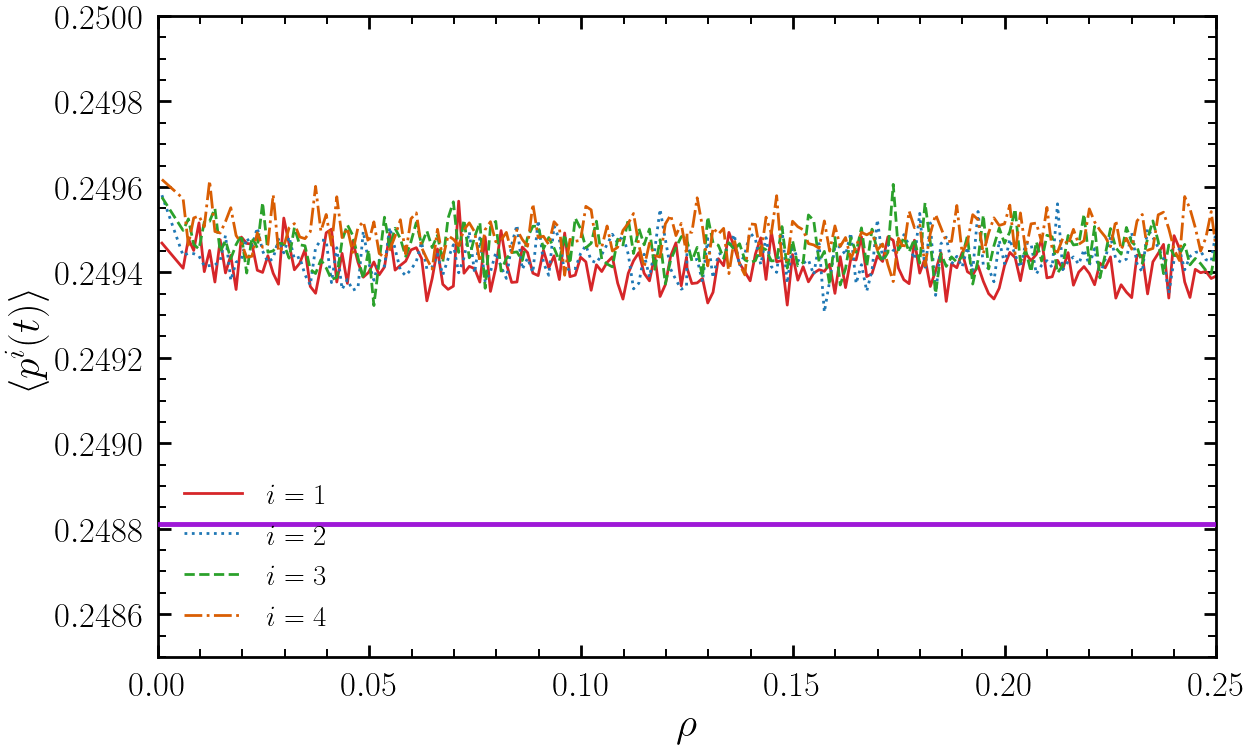

In [37]:
nc= 4
orders = [i for i in range(1,nc+1)]
L_lst = [1024]
ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

colors = [
    (0.84, 0.15, 0.16),  # vermelho forte
    (0.12, 0.47, 0.71),  # azul profundo
    (0.17, 0.63, 0.17),  # verde médio escuro
    (0.85, 0.37, 0.01),  # laranja queimado
    (0.58, 0.40, 0.74),  # roxo
    (0.55, 0.34, 0.29),  # marrom
    (0.09, 0.75, 0.81),  # ciano forte (escuro o suficiente)
    (0.50, 0.50, 0.50),  # cinza médio (ótimo para contraste sem brigar)
]

fig, ax = plt.subplots(figsize=(13, 8),
    sharex=True,
    sharey=True
)
pc = 0.24881182
fs_ticks = 25
fs_labels = 30
fs_legend_global = 29
fs_legend_local = 29
thickness= 2.0
# (5) separado por linha
fs_legend_local_top = 24
fs_legend_local_bottom = 30
thickness_axes = 2.0
fs_text = 35

lw_dados = 2.0
lw_pmean = 3.3
lw_pc = 3.5

tick_w = 1.8
tick_len = 9

# =========================
# PLOT DOS DADOS
# =========================
for idx_L, L in enumerate(L_lst):
    for idx_ord, ord in enumerate(orders):
        df_sub = df[(df['L']==L) & (df['dim']==3) & (df['nc']==nc)]
        df_sub_ord = df_sub[df_sub['order']==ord]

        ax.plot(
            df_sub_ord['rho'],
            df_sub_ord['p_mean'],
            linestyle=ls[idx_ord],
            color=colors[idx_ord],
            lw=lw_dados,
            label=f"$i = {ord}$"
        )

# linha pc
ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

# =========================
# FORMATAÇÃO
# =========================
ax.set_xlim([0, 1/nc])
ax.set_xlabel(r"$\rho$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.tick_params(axis='both', which='major',
               labelsize=fs_ticks, length=9, width=thickness, pad=10)

ax.legend(fontsize=21)
ax.set_ylim([0.2485, 0.25])
for spine in ax.spines.values():
    spine.set_linewidth(thickness_axes)

plt.tight_layout()
#plt.savefig(results_folder + "/density_pc.pdf")
plt.show()

## $P_c$ for L = 512

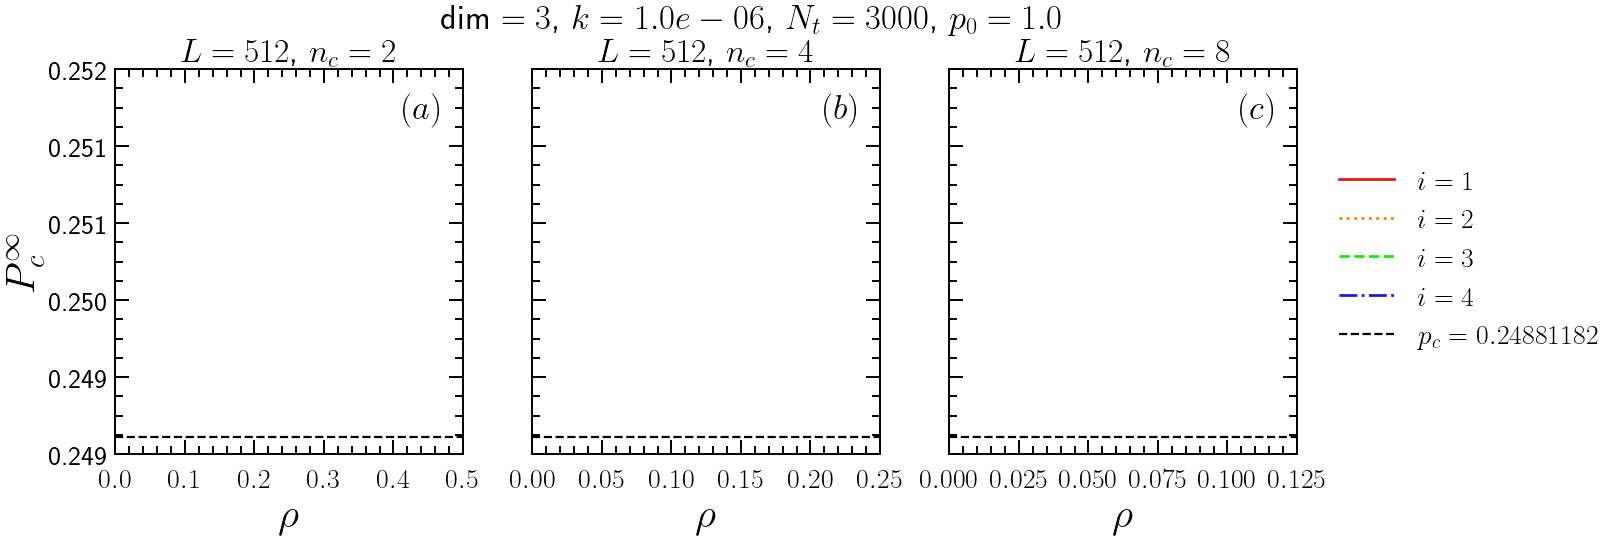

In [15]:
def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional

L = 512
NC_LIST = [2, 4, 8]
P0 = 0.1
p0 = 1.0
k=1.0e-06
DIM = 3
NT=3000
ylims = [(0.2, 1.1), (0.2, 0.37), (0.2, 0.37)]
pc_reff =  0.24881182
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True,sharex='col')  # 3x3 grid
thickness_axes = 1.4
WINDOW = 5
NC_list = [2, 4, 8]
ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]
colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.8, 0.2, 0.8),  # 6 - purple
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
labels_fig = ["$(a)$", "$(b)$", "$(c)$"]

legend_lines = {}
# Laço para cada linha de L
for i, nc in enumerate(NC_list):
        ax = axes[i]
        orders = [i for i in range(1, nc+1)]

        for idx_ord, order in enumerate(orders):
            df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"] == P0) & (df["p0"] == p0)].copy()
            if df_f.empty:
                continue
            df_f = df_f.sort_values("rho")

            x = df_f["rho"].to_numpy()
            y = df_f["p_mean"].to_numpy()

            y_ma = (
                pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW // 2)).mean().to_numpy()
            )
            y_std = (
                pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW // 2)).std().to_numpy()
            )
            y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y) + 1)))

            ax.plot(x, y, alpha=0.35)
            lines, = ax.plot(x, y_ma, linewidth=2, ls=ls[idx_ord], color=colors[idx_ord],label=f"$i = {order}$")
            ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
            rho_max = max(x)
            rho_min = min(x)
            
            if order not in legend_lines:
                legend_lines[order] = lines
        
        
        ax.set_title(rf"$L = {L}$, $n_c = {nc}$")
        
        ax.set_xlim([0, 1 / nc])
        
        ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)

        ax.axhline(y=pc_reff, color='k', linestyle='--', linewidth=1.6, label=f'$p_c = {pc_reff}$')
        
        aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f')
        
        ax.tick_params(axis='y', which='both', labelleft=False)
        
        if( i == 0):
            ax.tick_params(axis='y', which='both', labelleft=True, pad=5)
            ax.set_ylabel(r"$P_c^{\infty}$", fontsize=30)
    
        ax.tick_params(axis='x', which='both', labelbottom=True,pad=10)
        ax.set_xlabel(r"$\rho$", fontsize=30)

        ax.text(0.95, 0.85, labels_fig[i],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

fig.subplots_adjust(right=0.82)


handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# Adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')  # Linha para p_c
handles.append(pc_handle)
labels.append(fr'$p_c={pc_reff}$')  # Adicionando rótulo corretamente

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.83, 0.5),
           frameon=False)

fig.suptitle(fr"dim $= {DIM}$, $k = {k:.1e}$, $N_t = {NT}$, $p_0 = {p0}$", 
             fontsize=25, 
             fontweight='bold',
             y=1.01 )  # Adds a title to the entire figure

#plt.savefig(results_folder + "/rho/rho_PC_L_512_nc.pdf")
plt.show()

## $\rho_{min}$ versus L

# Figure tese

In [3]:
tese_folder = "../results/tese/time_moments"
create_folder(tese_folder)

def aplicar_ticks(ax,
                  n_yticks=6,
                  yfmt='%.3f',
                  x_major_step=50,
                  x_minor_step=10,
                  n_yminor=4):
    """
    x_major_step: passo entre major ticks de x (inteiro)
    x_minor_step: passo entre minor ticks de x (inteiro)
    n_yticks    : nº de major ticks em y (como antes)
    n_yminor    : nº de subdivisões em y (como antes)
    """

    # ---------- EIXO X: SOMENTE INTEIROS ----------
    # major em múltiplos inteiros de x_major_step
    if x_major_step is not None:
        ax.xaxis.set_major_locator(MultipleLocator(base=x_major_step))

    # minor também em inteiros (múltiplos de x_minor_step)
    if x_minor_step is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(base=x_minor_step))

    # ---------- EIXO Y: igual ao que você já usava ----------
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    if n_yminor is not None and n_yminor > 0:
        ax.yaxis.set_minor_locator(AutoMinorLocator(n_yminor + 1))

    # estilo geral dos ticks
    ax.tick_params(axis='both', which='major',
                   direction='in', top=True, right=True, length=13,labelsize=22)
    ax.tick_params(axis='both', which='minor',
                   direction='in', top=True, right=True, length=7,labelsize=22)

    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))

L = 256
nc = 4
P0 = 0.1
p0 = 1.0
k = 1.0e-06
DIM = 3
NT = 3000
rho = 1/nc
pc_reff = 0.24881182

path_json = f"../network/{DIM}D_L{L}_nc{nc}_rho{rho}_k{k:.1e}_Nt{NT}/P0_0.10_p0_1.00_seed_1.json"
data = read_orders_one_file_fix(path_json)['results']

# diminui o espaçamento vertical com gridspec_kw OU ajustando depois
fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 11),
    sharey=False,
    sharex='col',
    gridspec_kw={'hspace': 0.05}  # <-- menos espaço entre os dois plots
)

thickness_axes = 1.4
WINDOW = 5

ls = ['solid', 'dotted', 'dashed', 'dashdot']
lw = 2.4
legend_lines = {}
specific_times = [20, 60, 100]

colors_used = [
    (0.1, 0.1, 0.9),  # 3 - blue
    (0.2, 0.8, 0.8),  # 4 - teal
    (0.9, 0.1, 0.1),  # 1 - red
    (0.1, 0.9, 0.1),  # 4 - green
    
]

contrast_color = (0.9, 0.1, 0.9)  # magenta bem contrastante

for i in range(2):
    ax = axes[i]
    orders = [i for i in range(1, nc+1)]

    for idx_ord, order in enumerate(orders):
        data_filter = data[f'order_percolation {order}']['data']
        x = data_filter['time']  # time
        if i == 0:
            y = data_filter['pt']
        elif i == 1:
            y = data_filter['nt']

        line, = ax.plot(x, y, ls=ls[idx_ord], lw=lw ,alpha=1.0, color=colors_used[idx_ord])
        x_max = max(x)
        x_min = min(x)

        if order not in legend_lines:
            legend_lines[order] = line

    ax.set_xlim(x_min, x_max)
    # ax.set_ylim(ylims[i])  # se quiser limites específicos

    # aplica major + minor ticks com espaçamento controlado
    # ajuste n_xticks/n_yticks/n_xminor/n_yminor conforme desejar
    

    # espessura dos eixos
    ax.tick_params(axis='both', which='major',
                   labelsize=20, width=thickness_axes)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)

    # labels de eixo y em ambos (você já força isso abaixo)
    ax.tick_params(axis='y', which='both', labelleft=True)

    # linhas horizontais COM legenda dentro de cada plot
    if i == 0:
        hline = ax.axhline(y=pc_reff, color='k', linestyle='--',
                           linewidth=1.6, label=fr'$p_c = {pc_reff}$')
        ax.set_ylabel(r"$p(t)$", fontsize=30)
        # legenda só para essa linha, dentro do painel
        ax.legend(loc='upper right', frameon=False, fontsize=25)
        aplicar_ticks(ax,
                    n_yticks=6,
                    yfmt='%.1f',
                    x_major_step=100,  # major: 0, 100, 200, ...
                    x_minor_step=20,   # minor: 0, 20, 40, 60, ...
                    n_yminor=4)

    if i == 1:
        aplicar_ticks(ax,
                    n_yticks=6,
                    yfmt='%1d',
                    x_major_step=100,  # major: 0, 100, 200, ...
                    x_minor_step=20,   # minor: 0, 20, 40, 60, ...
                    n_yminor=4)
        hline = ax.axhline(y=NT, color='k', linestyle='--',
                           linewidth=1.6, label=fr'$N_T = {NT}$')
        ax.set_ylabel(r"$N(t)$", fontsize=30)
        ax.tick_params(axis='x', which='both', labelbottom=True)
        ax.set_xlabel(r"$t$", fontsize=30)
        # legenda para a linha horizontal deste painel
        ax.legend(loc='upper right', frameon=False, fontsize=25)
    for sp in specific_times:
        ax.axvline(x=sp, ymax=1.0, ymin=0.0, ls='solid',lw=2.2 ,color=contrast_color)
    
    # rótulo (a), (b)
    # ax.text(0.85, 0.72, labels_fig[i],
    #         transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

# ajusta bordas e espaço lateral p/ legenda global
fig.subplots_adjust(right=0.82, hspace=0.08)

# legenda global só para as ordens i
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

fig.legend(handles, labels,
           loc='center left',
           bbox_to_anchor=(0.83, 0.5),
           fontsize=25,
           frameon=False)
out_file = tese_folder + "/propeties.png"

fig.suptitle(
    fr"dim $= {DIM}$, $k = {k:.1e}$, $N_t = {NT}$, $p_0 = {p0}$, $L = {L}$",
    fontsize=25,
    fontweight='bold',
    y=0.93
)

fig.tight_layout()

fig.savefig(
    out_file,    # ou .png
    bbox_inches="tight",
    pad_inches=0.02,       # pequena margem extra ao redor
    dpi=300                # se for raster (png)
)
plt.show()


Folder already exists: ../results/tese/time_moments


NameError: name 'read_orders_one_file_fix' is not defined